# Unit Economics & Churn Driver Analysis
**Dataset:** RavenStack — subscriptions + churn_events  
**Goal:** Calculate LTV, churn rate, and payback metrics by plan tier; identify dominant churn reason per tier

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import openpyxl
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('Libraries loaded.')

Libraries loaded.


In [2]:
accounts     = pd.read_csv('../data/accounts.csv', parse_dates=['signup_date'])
subs         = pd.read_csv('../data/subscriptions.csv', parse_dates=['start_date', 'end_date'])
churn_events = pd.read_csv('../data/churn_events.csv', parse_dates=['churn_date'])

print(f'Accounts:     {len(accounts):,}')
print(f'Subscriptions:{len(subs):,}')
print(f'Churn events: {len(churn_events):,}')
print(f'\nPlan tiers in subscriptions: {subs["plan_tier"].unique()}')
print(f'Churn reason codes: {churn_events["reason_code"].unique()}')

Accounts:     500
Subscriptions:5,000
Churn events: 600

Plan tiers in subscriptions: ['Enterprise' 'Pro' 'Basic']
Churn reason codes: ['pricing' 'support' 'budget' 'unknown' 'features' 'competitor']


## Step 1: Unit Economics by Plan Tier

In [3]:
# Filter out trials for unit economics
paid = subs[subs['is_trial'] == False].copy()

# Lifespan: for churned subs, compute months between start and end
paid['lifespan_months'] = np.where(
    paid['churn_flag'] == True,
    (paid['end_date'] - paid['start_date']).dt.days / 30.44,
    np.nan  # exclude active (right-censored) from avg lifespan
)

rows = []
ANALYSIS_DATE = pd.Timestamp('2025-01-01')

for tier in ['Basic', 'Pro', 'Enterprise']:
    t = paid[paid['plan_tier'] == tier]
    active = t[t['churn_flag'] == False]
    churned = t[t['churn_flag'] == True]

    # Avg MRR across active accounts
    avg_mrr = active['mrr_amount'].mean() if len(active) > 0 else t['mrr_amount'].mean()

    # Avg lifespan from churned subscriptions only
    avg_lifespan = churned['lifespan_months'].mean() if len(churned) > 0 else np.nan

    # LTV = Avg MRR × Avg Lifespan
    ltv = avg_mrr * avg_lifespan if not np.isnan(avg_lifespan) else np.nan

    # Monthly Churn Rate = churned accounts / total accounts in tier
    total_accs = accounts[accounts['plan_tier'] == tier]
    churned_accs = total_accs[total_accs['churn_flag'] == True]
    # Annualise: spread over observation period
    months_observed = max(
        (ANALYSIS_DATE - subs['start_date'].min()).days / 30.44, 1
    )
    monthly_churn_rate = (len(churned_accs) / len(total_accs)) / months_observed * 12 if len(total_accs) > 0 else np.nan
    # Cap at sensible range
    monthly_churn_rate = min(monthly_churn_rate, 1.0)

    # LTV:MRR = LTV / Avg MRR = Avg Lifespan
    ltv_mrr = ltv / avg_mrr if (avg_mrr and not np.isnan(ltv)) else np.nan

    rows.append({
        'Plan Tier': tier,
        'Active Subs': len(active),
        'Churned Subs': len(churned),
        'Avg MRR ($)': round(avg_mrr, 2),
        'Avg Lifespan (mo)': round(avg_lifespan, 1) if not np.isnan(avg_lifespan) else '-',
        'LTV ($)': round(ltv, 0) if not np.isnan(ltv) else '-',
        'Monthly Churn Rate': f'{monthly_churn_rate:.1%}' if not np.isnan(monthly_churn_rate) else '-',
        'LTV:MRR Ratio': round(ltv_mrr, 1) if not np.isnan(ltv_mrr) else '-'
    })

unit_econ = pd.DataFrame(rows)
print('Unit Economics by Plan Tier:')
print(unit_econ.to_string(index=False))

Unit Economics by Plan Tier:
 Plan Tier  Active Subs  Churned Subs  Avg MRR ($)  Avg Lifespan (mo)  LTV ($) Monthly Churn Rate  LTV:MRR Ratio
     Basic         1228           128       560.19                3.2   1765.0              11.1%            3.2
       Pro         1282           134      1501.42                2.5   3758.0              11.1%            2.5
Enterprise         1304           146      5787.48                2.7  15775.0              11.2%            2.7


## Step 2: Churn Driver Analysis — reason_code × plan_tier

In [4]:
# Join churn_events with accounts to get plan_tier
churn_with_tier = churn_events.merge(
    accounts[['account_id', 'plan_tier']],
    on='account_id', how='left'
)

# Cross-tab: reason_code × plan_tier (counts)
crosstab = pd.crosstab(
    churn_with_tier['reason_code'],
    churn_with_tier['plan_tier'],
    margins=True,
    margins_name='Total'
)

# Reorder columns
cols = [c for c in ['Basic', 'Pro', 'Enterprise', 'Total'] if c in crosstab.columns]
crosstab = crosstab[cols]

print('Churn Reason × Plan Tier (count of events):')
print(crosstab.to_string())

# Percentage within each tier
crosstab_pct = pd.crosstab(
    churn_with_tier['reason_code'],
    churn_with_tier['plan_tier'],
    normalize='columns'
).round(3) * 100

print('\nChurn Reason × Plan Tier (% of tier):')
print(crosstab_pct.to_string())

Churn Reason × Plan Tier (count of events):
plan_tier    Basic  Pro  Enterprise  Total
reason_code                               
budget          30   40          34    104
competitor      25   36          31     92
features        34   41          39    114
pricing         29   30          32     91
support         37   43          24    104
unknown         25   35          35     95
Total          180  225         195    600

Churn Reason × Plan Tier (% of tier):
plan_tier    Basic  Enterprise   Pro
reason_code                         
budget        16.7        17.4  17.8
competitor    13.9        15.9  16.0
features      18.9        20.0  18.2
pricing       16.1        16.4  13.3
support       20.6        12.3  19.1
unknown       13.9        17.9  15.6


## Step 3: Strategic Recommendations by Tier

In [5]:
# Find dominant churn reason per tier
print('=' * 60)
print('DOMINANT CHURN REASON PER TIER')
print('=' * 60)

recommendations = {}
for tier in ['Basic', 'Pro', 'Enterprise']:
    if tier in crosstab_pct.columns:
        top_reason = crosstab_pct[tier].idxmax()
        top_pct = crosstab_pct[tier].max()
        
        recs = {
            'pricing':     f'Introduce a discounted annual plan or flexible seat pricing to reduce price-sensitivity churn — {top_pct:.0f}% of {tier} churns are pricing-related.',
            'support':     f'Deploy a dedicated CSM touchpoint at 30/60/90 days post-signup to intercept at-risk {tier} accounts before support frustration escalates to churn.',
            'features':    f'Prioritise feature gap closure for {tier} tier — {top_pct:.0f}% of churns cite missing features; a structured roadmap communication cadence would reduce this.',
            'budget':      f'Offer budget-cycle flexible payment terms or usage-based downgrades (rather than full churn) for {tier} accounts facing budget constraints.',
            'competitor':  f'Conduct win/loss interviews among churned {tier} accounts to identify the specific competitor advantage; address with targeted battle-cards for sales.',
            'performance': f'Invest in reliability SLAs and proactive monitoring alerts for {tier} accounts to address performance-driven churn ({top_pct:.0f}% of churns).',
            'other':       f'Investigate the unclassified churn reasons in {tier} tier to identify emerging themes not yet captured in reason codes.'
        }
        
        rec = recs.get(top_reason, f'Address {top_reason} issues as the leading churn driver ({top_pct:.0f}%) for {tier} tier.')
        recommendations[tier] = (top_reason, top_pct, rec)
        
        print(f'\n{tier} Tier:')
        print(f'  Dominant reason: {top_reason} ({top_pct:.0f}%)')
        print(f'  Recommendation: {rec}')

print('\n' + '=' * 60)

DOMINANT CHURN REASON PER TIER

Basic Tier:
  Dominant reason: support (21%)
  Recommendation: Deploy a dedicated CSM touchpoint at 30/60/90 days post-signup to intercept at-risk Basic accounts before support frustration escalates to churn.

Pro Tier:
  Dominant reason: support (19%)
  Recommendation: Deploy a dedicated CSM touchpoint at 30/60/90 days post-signup to intercept at-risk Pro accounts before support frustration escalates to churn.

Enterprise Tier:
  Dominant reason: features (20%)
  Recommendation: Prioritise feature gap closure for Enterprise tier — 20% of churns cite missing features; a structured roadmap communication cadence would reduce this.



## Step 4: Visualisations

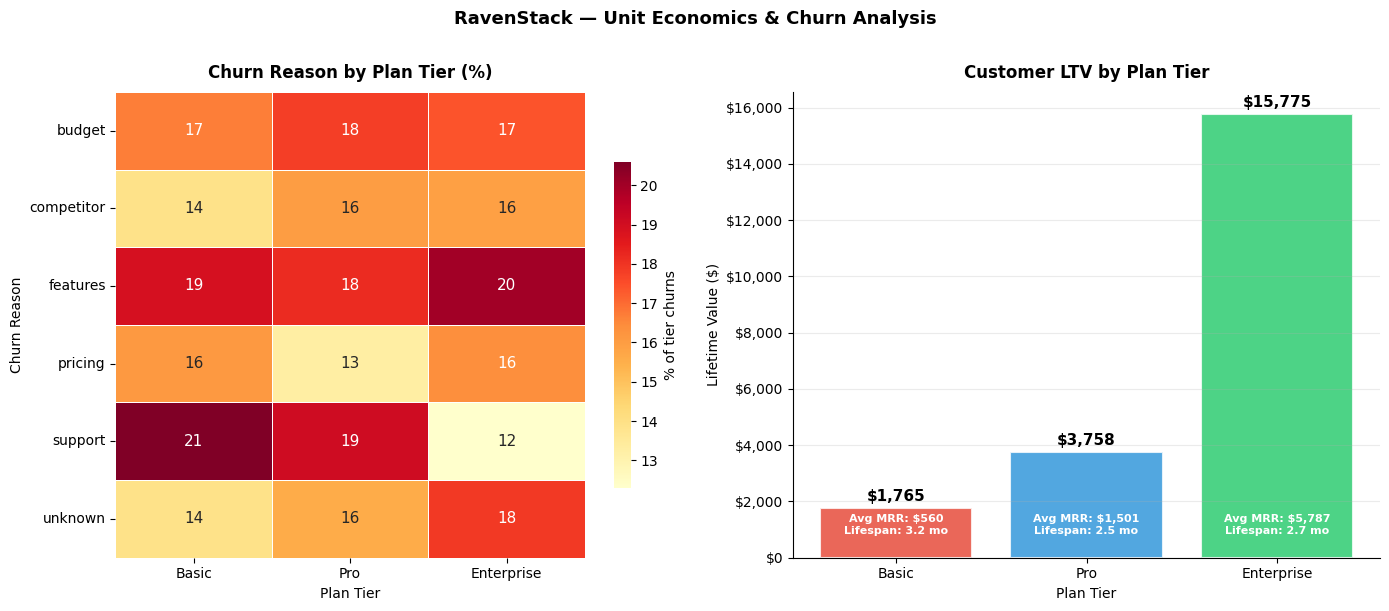

Saved: unit_economics_charts.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: Churn reason heatmap (%) ---
ax1 = axes[0]
hm_data = crosstab_pct[[c for c in ['Basic', 'Pro', 'Enterprise'] if c in crosstab_pct.columns]]
sns.heatmap(
    hm_data,
    ax=ax1,
    cmap='YlOrRd',
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    cbar_kws={'label': '% of tier churns', 'shrink': 0.7},
    annot_kws={'size': 11}
)
ax1.set_title('Churn Reason by Plan Tier (%)', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Plan Tier', fontsize=10)
ax1.set_ylabel('Churn Reason', fontsize=10)
ax1.tick_params(axis='y', rotation=0)

# --- Right: LTV comparison bar chart ---
ax2 = axes[1]
ltv_vals = []
ltv_labels = []
for _, row in unit_econ.iterrows():
    ltv = row['LTV ($)']
    if ltv != '-':
        ltv_vals.append(float(ltv))
        ltv_labels.append(row['Plan Tier'])

tier_colors = {'Basic': '#e74c3c', 'Pro': '#3498db', 'Enterprise': '#2ecc71'}
bar_colors = [tier_colors.get(t, '#999') for t in ltv_labels]

bars = ax2.bar(ltv_labels, ltv_vals, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=1.5)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for bar, val in zip(bars, ltv_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(ltv_vals)*0.01,
             f'${val:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax2.set_title('Customer LTV by Plan Tier', fontsize=12, fontweight='bold', pad=10)
ax2.set_ylabel('Lifetime Value ($)', fontsize=10)
ax2.set_xlabel('Plan Tier', fontsize=10)
ax2.grid(axis='y', alpha=0.25)

# Add MRR and lifespan annotations
for _, row in unit_econ.iterrows():
    if row['Plan Tier'] in ltv_labels:
        ax2.text(
            ltv_labels.index(row['Plan Tier']),
            max(ltv_vals) * 0.05,
            f"Avg MRR: ${row['Avg MRR ($)']:,.0f}\nLifespan: {row['Avg Lifespan (mo)']} mo",
            ha='center', va='bottom', fontsize=8, color='white', fontweight='bold'
        )

plt.suptitle('RavenStack — Unit Economics & Churn Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/unit_economics_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: unit_economics_charts.png')

## Step 5: Export to Excel with Formatting

In [7]:
OUTPUT_PATH = '../outputs/unit_economics_table.xlsx'

wb = openpyxl.Workbook()

# ── Sheet 1: Unit Economics ──────────────────────────────────────
ws1 = wb.active
ws1.title = 'Unit Economics'

HEADER_FILL  = PatternFill('solid', fgColor='1A1A2E')
BASIC_FILL   = PatternFill('solid', fgColor='FDECEA')
PRO_FILL     = PatternFill('solid', fgColor='EBF5FB')
ENT_FILL     = PatternFill('solid', fgColor='EAFAF1')
TIER_FILLS   = {'Basic': BASIC_FILL, 'Pro': PRO_FILL, 'Enterprise': ENT_FILL}

HEADER_FONT  = Font(bold=True, color='FFFFFF', size=11)
TITLE_FONT   = Font(bold=True, size=13)
BOLD_FONT    = Font(bold=True, size=10)
NORMAL_FONT  = Font(size=10)

thin = Side(border_style='thin', color='CCCCCC')
BORDER = Border(left=thin, right=thin, top=thin, bottom=thin)

# Title
ws1['A1'] = 'RavenStack SaaS — Unit Economics by Plan Tier'
ws1['A1'].font = TITLE_FONT
ws1.merge_cells('A1:H1')
ws1['A1'].alignment = Alignment(horizontal='center')

ws1['A2'] = 'Analysis Date: January 2025 | Source: RavenStack synthetic dataset (5,000 subscription records)'
ws1['A2'].font = Font(italic=True, size=9, color='666666')
ws1.merge_cells('A2:H2')

# Headers (row 4)
headers = list(unit_econ.columns)
for col_idx, header in enumerate(headers, 1):
    cell = ws1.cell(row=4, column=col_idx, value=header)
    cell.fill = HEADER_FILL
    cell.font = HEADER_FONT
    cell.alignment = Alignment(horizontal='center', wrap_text=True)
    cell.border = BORDER

# Data rows
for row_idx, data_row in unit_econ.iterrows():
    tier = data_row['Plan Tier']
    fill = TIER_FILLS.get(tier, PatternFill())
    for col_idx, value in enumerate(data_row, 1):
        cell = ws1.cell(row=row_idx + 5, column=col_idx, value=value)
        cell.fill = fill
        cell.font = BOLD_FONT if col_idx == 1 else NORMAL_FONT
        cell.alignment = Alignment(horizontal='center')
        cell.border = BORDER

# Column widths
col_widths = [14, 13, 14, 14, 18, 12, 20, 16]
for i, w in enumerate(col_widths, 1):
    ws1.column_dimensions[get_column_letter(i)].width = w
ws1.row_dimensions[4].height = 35

# ── Sheet 2: Churn Drivers ───────────────────────────────────────
ws2 = wb.create_sheet('Churn Drivers')

ws2['A1'] = 'Churn Reason × Plan Tier — Count & Percentage'
ws2['A1'].font = TITLE_FONT
ws2.merge_cells('A1:E1')
ws2['A1'].alignment = Alignment(horizontal='center')

# Count table
ws2['A3'] = 'Count of Churn Events'
ws2['A3'].font = Font(bold=True, size=10)

ct_display = crosstab[[c for c in ['Basic', 'Pro', 'Enterprise', 'Total'] if c in crosstab.columns]]
ws2.cell(row=4, column=1, value='Reason Code').font = HEADER_FONT
ws2.cell(row=4, column=1).fill = HEADER_FILL
ws2.cell(row=4, column=1).border = BORDER

for col_idx, col_name in enumerate(ct_display.columns, 2):
    c = ws2.cell(row=4, column=col_idx, value=col_name)
    c.fill = HEADER_FILL
    c.font = HEADER_FONT
    c.alignment = Alignment(horizontal='center')
    c.border = BORDER

for row_idx, (reason, row_data) in enumerate(ct_display.iterrows(), 5):
    ws2.cell(row=row_idx, column=1, value=reason).font = BOLD_FONT
    ws2.cell(row=row_idx, column=1).border = BORDER
    for col_idx, val in enumerate(row_data, 2):
        c = ws2.cell(row=row_idx, column=col_idx, value=int(val))
        c.alignment = Alignment(horizontal='center')
        c.border = BORDER

# Percentage table
pct_start_row = 5 + len(ct_display) + 2
ws2.cell(row=pct_start_row, column=1, value='% of Tier Churns').font = Font(bold=True, size=10)

ct_pct_display = crosstab_pct[[c for c in ['Basic', 'Pro', 'Enterprise'] if c in crosstab_pct.columns]]
ws2.cell(row=pct_start_row+1, column=1, value='Reason Code').font = HEADER_FONT
ws2.cell(row=pct_start_row+1, column=1).fill = HEADER_FILL
ws2.cell(row=pct_start_row+1, column=1).border = BORDER

for col_idx, col_name in enumerate(ct_pct_display.columns, 2):
    c = ws2.cell(row=pct_start_row+1, column=col_idx, value=col_name)
    c.fill = HEADER_FILL
    c.font = HEADER_FONT
    c.alignment = Alignment(horizontal='center')
    c.border = BORDER

for row_idx, (reason, row_data) in enumerate(ct_pct_display.iterrows(), pct_start_row+2):
    ws2.cell(row=row_idx, column=1, value=reason).font = BOLD_FONT
    ws2.cell(row=row_idx, column=1).border = BORDER
    for col_idx, val in enumerate(row_data, 2):
        c = ws2.cell(row=row_idx, column=col_idx, value=f'{val:.1f}%')
        c.alignment = Alignment(horizontal='center')
        c.border = BORDER

# Recommendations sheet
ws3 = wb.create_sheet('Strategic Recommendations')
ws3['A1'] = 'Churn Driver Strategic Recommendations'
ws3['A1'].font = TITLE_FONT
ws3.merge_cells('A1:D1')

rec_headers = ['Plan Tier', 'Top Churn Reason', '% of Tier Churns', 'Strategic Recommendation']
for col_idx, h in enumerate(rec_headers, 1):
    c = ws3.cell(row=3, column=col_idx, value=h)
    c.fill = HEADER_FILL
    c.font = HEADER_FONT
    c.alignment = Alignment(horizontal='center', wrap_text=True)
    c.border = BORDER

for row_idx, (tier, (reason, pct, rec)) in enumerate(recommendations.items(), 4):
    fill = TIER_FILLS.get(tier, PatternFill())
    for col_idx, val in enumerate([tier, reason, f'{pct:.0f}%', rec], 1):
        c = ws3.cell(row=row_idx, column=col_idx, value=val)
        c.fill = fill
        c.font = BOLD_FONT if col_idx == 1 else NORMAL_FONT
        c.alignment = Alignment(wrap_text=True, vertical='top')
        c.border = BORDER
    ws3.row_dimensions[row_idx].height = 60

ws3.column_dimensions['A'].width = 14
ws3.column_dimensions['B'].width = 18
ws3.column_dimensions['C'].width = 18
ws3.column_dimensions['D'].width = 60

wb.save(OUTPUT_PATH)
print(f'Saved: {OUTPUT_PATH}')
print('Sheets: Unit Economics | Churn Drivers | Strategic Recommendations')

Saved: ../outputs/unit_economics_table.xlsx
Sheets: Unit Economics | Churn Drivers | Strategic Recommendations


## Step 6: Final Summary for Investor Narrative

In [8]:
print('=' * 60)
print('UNIT ECONOMICS SUMMARY — KEY NUMBERS')
print('=' * 60)
for _, row in unit_econ.iterrows():
    print(f"\n{row['Plan Tier']} Tier:")
    print(f"  Avg MRR:          ${row['Avg MRR ($)']:>8,.2f}")
    print(f"  Avg Lifespan:     {row['Avg Lifespan (mo)']:>6} months")
    print(f"  LTV:              {str(row['LTV ($)']):>8}")
    print(f"  Monthly Churn:    {row['Monthly Churn Rate']:>6}")
    print(f"  LTV:MRR Ratio:    {str(row['LTV:MRR Ratio']):>6}x")

print('\n' + '=' * 60)
print('CHURN DRIVER SUMMARY')
print('=' * 60)
for tier, (reason, pct, rec) in recommendations.items():
    print(f'  {tier}: {reason} ({pct:.0f}%)')

print('\nAll outputs saved to ../outputs/')
print('=' * 60)

UNIT ECONOMICS SUMMARY — KEY NUMBERS

Basic Tier:
  Avg MRR:          $  560.19
  Avg Lifespan:        3.2 months
  LTV:                1765.0
  Monthly Churn:     11.1%
  LTV:MRR Ratio:       3.2x

Pro Tier:
  Avg MRR:          $1,501.42
  Avg Lifespan:        2.5 months
  LTV:                3758.0
  Monthly Churn:     11.1%
  LTV:MRR Ratio:       2.5x

Enterprise Tier:
  Avg MRR:          $5,787.48
  Avg Lifespan:        2.7 months
  LTV:               15775.0
  Monthly Churn:     11.2%
  LTV:MRR Ratio:       2.7x

CHURN DRIVER SUMMARY
  Basic: support (21%)
  Pro: support (19%)
  Enterprise: features (20%)

All outputs saved to ../outputs/
